In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## exercícios 1 e 2
Leia os dados com erro novamente, faça a limpeza e remova as duas últimas colunas, e insira a mediana nas entradas NaN

In [143]:
data = pd.read_csv('data/iris-with-errors.csv')
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
1,5.1,3.5,1.4,0.2,duplicada
2,?,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,5.1,3.5,1.4,0.2,duplicada


In [144]:
## data.drop_duplicates()
label_dup = data[data.duplicated()].index
ndata = data.drop(labels=label_dup)

## drop columns
ndata = ndata.drop(labels = ['petal_width', 'species'], axis=1)

## replace missing values
for i in ndata.columns:
    ndata[i] = ndata[i].replace('?', np.nan)
    ndata[i] = ndata[i].replace(np.nan, ndata[i].median(skipna=True))

In [145]:
ndata.head()

,sepal_length,sepal_width,petal_length
0,5.1,3.5,1.4
2,5.0,3,1.4
3,4.7,3.2,1.3
5,5.0,3.1,1.5
6,5,3.6,1.4


## exercícios 3 e 4
Conside os dados da Iris e mostre a distribuição de probabilidades de cada uma das variáveis após a normalização e padronização. Em seguida, reamostre os dados da Iris e selecione 10 elementos em cada classe.

In [146]:
#from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity

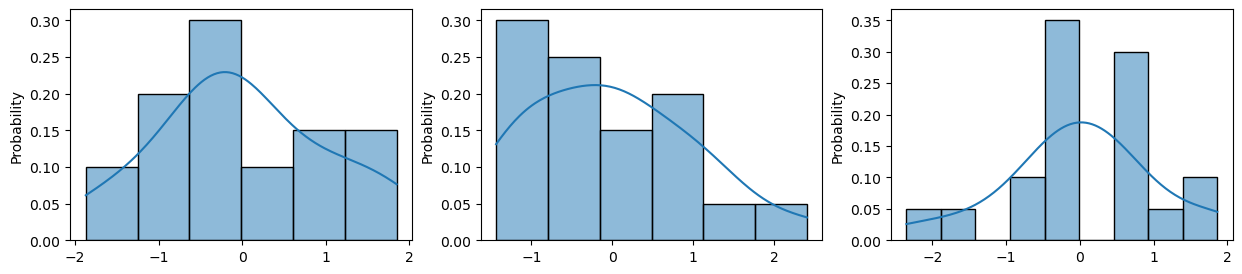

In [159]:
scldata = StandardScaler().fit_transform(ndata)

fig, axs = plt.subplots(1, 3, figsize=(15, 3))
count=0
for ax in axs:
    sns.histplot(scldata[:,count], kde=True, stat="probability", ax=ax)
    count+=1

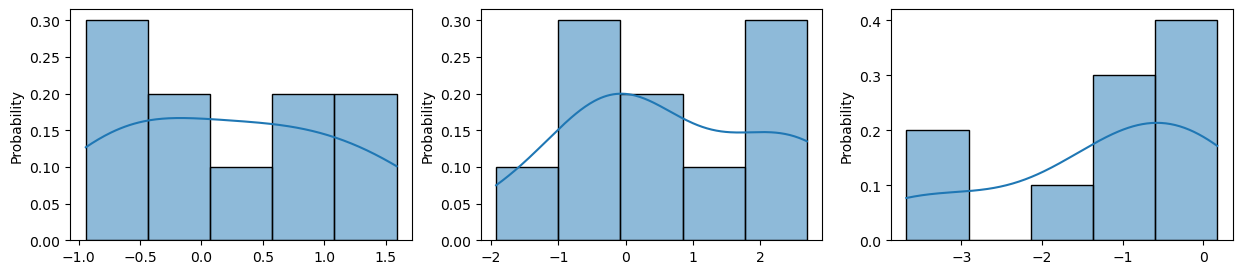

In [174]:
# this assumes that the features are independent random variables, i guess 
# (obviously, this is not true, so i need to figure out a better way to resample the data)

N = 10
kde0 = KernelDensity().fit(scldata[:, 0].reshape(-1,1))
kde1 = KernelDensity().fit(scldata[:, 1].reshape(-1,1)) 
kde2 = KernelDensity().fit(scldata[:, 2].reshape(-1,1))
a = kde0.sample(N)[:,0]
b = kde1.sample(N)[:,0]
c = kde2.sample(N)[:,0]
rsp_scldata = np.array([a,b,c]).T
#print(rsp_scldata)

fig, axs = plt.subplots(1, 3, figsize=(15, 3))
count=0
for ax in axs:
    sns.histplot(rsp_scldata[:,count], kde=True, stat="probability", ax=ax)
    count+=1